In [75]:
import pandas as pd
import numpy as np
%matplotlib inline
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'

In [76]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                            index_col=0, parse_dates=True).dropna()

In [77]:
data = pd.DataFrame(raw['GDX'])

In [78]:
data.rename(columns={'GDX': 'price'}, inplace=True)

In [79]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [80]:
SMA = 25

In [81]:
data['SMA'] = data['price'].rolling(SMA).mean()

In [82]:
threshold = 3.5

In [83]:
data['distance'] = data['price'] - data['SMA']

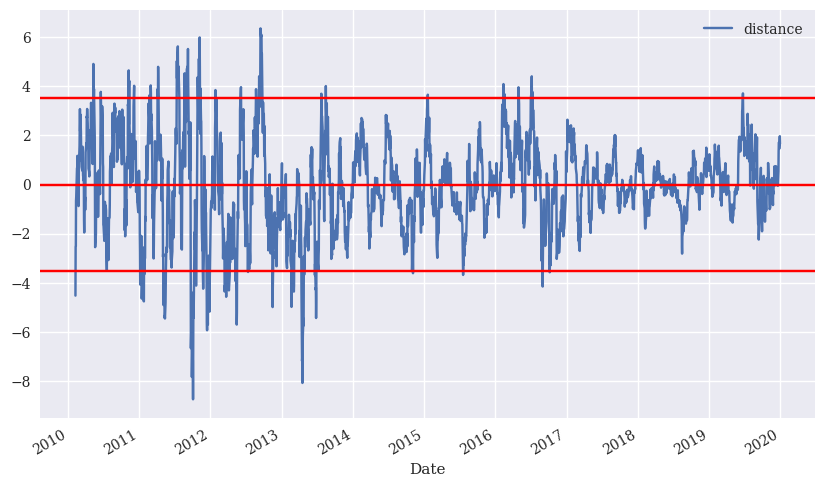

In [84]:
data[['distance']].dropna().plot(figsize=(10,6), legend=True)
plt.axhline(threshold, color='r')
plt.axhline(-threshold, color='r')
plt.axhline(0, color='r');

In [85]:
data['position'] = np.where(data['distance'] > threshold, 
                            -1, np.nan)

In [86]:
data['position'] = np.where(data['distance'] < -threshold,
                            1, data['position'])

In [87]:
data['position'] = np.where(data['distance'] *
                            data['distance'].shift(1) < 0, 0, data['position'])

In [88]:
data['position'] = data['position'].ffill().fillna(0)

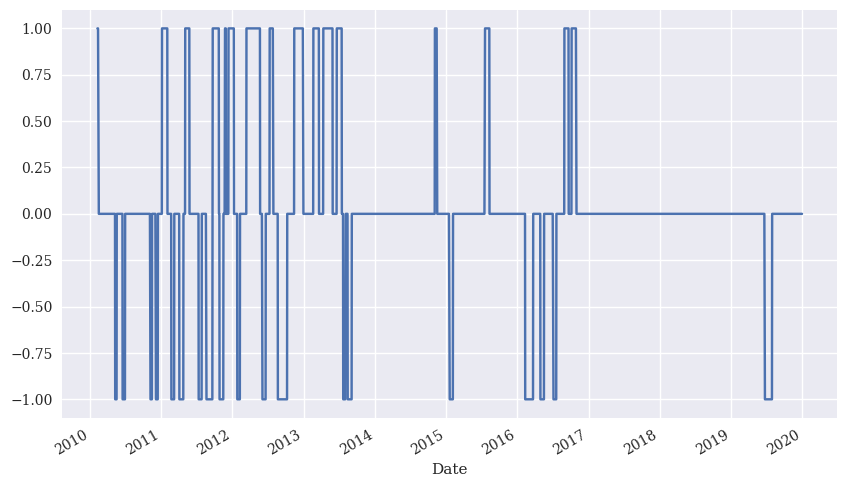

In [91]:
data['position'].iloc[SMA:].plot(ylim=[-1.1, 1.1],
                                 figsize=(10,6));

In [94]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

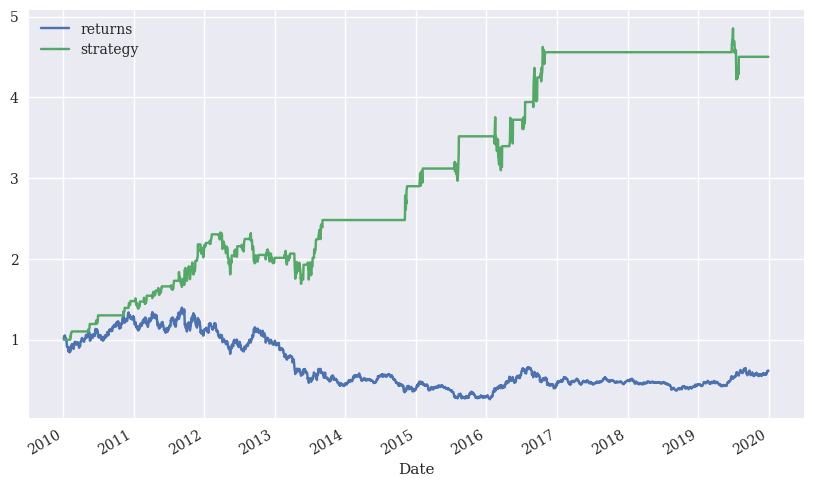

In [95]:
data[['returns', 'strategy']].dropna().cumsum( 
    ).apply(np.exp).plot(figsize=(10,6))
